
===== Linear Kernel =====
CV=2: 0.95
CV=5: 0.95
Accuracy: 0.9666666666666667
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30


===== RBF Kernel =====
CV=2: 0.8999999999999999
CV=5: 0.95
Accuracy: 1.0
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        

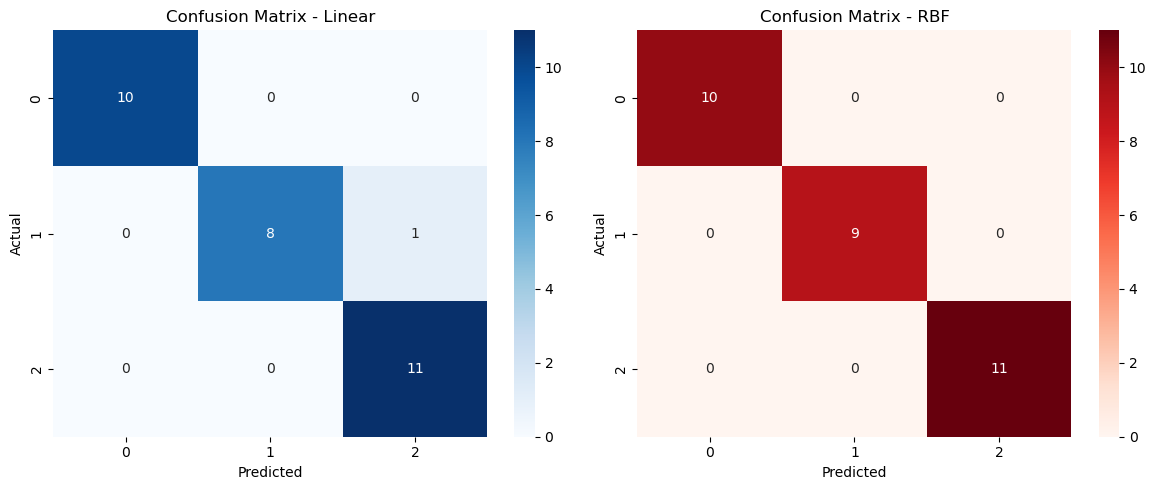

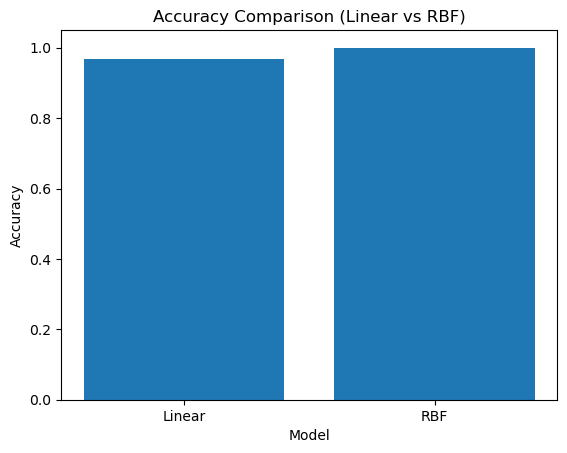

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv("iris.csv")
X = df.drop(["Species", "Id"], axis=1)
y = df["Species"]

#  Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  Models
models = {
    "Linear": SVC(kernel='linear'),
    "RBF": SVC(kernel='rbf')
}

colors = {
    "Linear": "Blues",
    "RBF": "Reds"
}

accuracies = []


#  Training + Evaluation + CM
plt.figure(figsize=(12, 5))

for i, (name, model) in enumerate(models.items()):
    
    print(f"\n===== {name} Kernel =====")
    
    # CV
    print("CV=2:", cross_val_score(model, X_train, y_train, cv=2).mean())
    print("CV=5:", cross_val_score(model, X_train, y_train, cv=5).mean())
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy 
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    # Evaluation
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    #  CM
    plt.subplot(1, 2, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap=colors[name])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# Accuracy Comparison Plot
plt.figure()
plt.bar(models.keys(), accuracies)
plt.title("Accuracy Comparison (Linear vs RBF)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()